# Part A — Big Data Analytics: Galle Cafes & Restaurants

**Project:** Big Data Analytics & Recommendation System for Cafes/Restaurants in Galle District, Sri Lanka

**Author:** *Pradeepa Subhashini Urala*  
---

## 1. Introduction

Galle District in southern Sri Lanka is one of the country's most important tourism hubs, anchored by the UNESCO World Heritage Site of Galle Fort and the surrounding beach towns of Unawatuna, Hikkaduwa, Mirissa, Koggala, and Ahangama. The hospitality industry in this region — particularly cafes and restaurants — plays a pivotal role in the local economy.

Despite the importance of this sector, publicly available domain-specific datasets for Sri Lankan tourism are limited. To address this gap, I constructed a **custom dataset of 809 cafes and restaurants** with **3,269 reviews** by collecting data programmatically from the Google Places API.

### Objectives of Part A

1. **Demonstrate Apache Spark / PySpark** for distributed data processing and analytics
2. **Load, clean, and transform** the collected dataset using Spark DataFrames
3. **Engineer features** that enable richer analysis
4. **Conduct Exploratory Data Analysis (EDA)** using Spark SQL and visualizations
5. **Apply big data analytics techniques** including K-Means clustering and text classification
6. **Discuss findings, limitations, and improvements**

### A Note on Dataset Size

At ~3,000 reviews, this dataset is modest in absolute terms. However, this project demonstrates **correct usage of distributed-computing techniques (PySpark DataFrame API, Spark SQL, and Spark MLlib)** that scale unchanged from thousands to billions of records. The methodology — not the raw size — is the focus.

---

## 2. Environment Setup

We install PySpark and supporting libraries for visualization (matplotlib, seaborn), text analytics (wordcloud, nltk), and general data manipulation.

In [39]:
# Install required packages
!pip install -q pyspark pandas matplotlib seaborn wordcloud nltk

In [40]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

# PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

# Set polished visualization style
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('All libraries imported successfully')

All libraries imported successfully


In [41]:
!apt-get install openjdk-17-jdk-headless -qq

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("GalleCafeAnalytics") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print(f"Spark version: {spark.version}")
print(f"Java version:")
!java -version
print(f"Spark UI available at: {spark.sparkContext.uiWebUrl}")

Spark version: 4.0.2
Java version:
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
Spark UI available at: http://828316e6f936:4040


## 3. Data Loading

Loaded the two CSV files into Spark DataFrames with explicit schemas. **Defining schemas explicitly** (rather than relying on `inferSchema=True`) is a Spark best practice that:
- Avoids an extra pass over the data
- Prevents type inference errors on edge cases
- Documents the expected structure for future maintainers

In [42]:
# Upload the CSVs to Colab

In [43]:
# Define schemas explicitly for type safety and performance
places_schema = StructType([
    StructField('place_id', StringType(), True),
    StructField('name', StringType(), True),
    StructField('address', StringType(), True),
    StructField('lat', DoubleType(), True),
    StructField('lng', DoubleType(), True),
    StructField('rating', DoubleType(), True),
    StructField('user_ratings_total', IntegerType(), True),
    StructField('price_level', DoubleType(), True),
    StructField('types', StringType(), True),
    StructField('phone', StringType(), True),
    StructField('website', StringType(), True),
    StructField('opening_hours', StringType(), True),
    StructField('business_status', StringType(), True),
    StructField('anchor_area', StringType(), True),
    StructField('search_type', StringType(), True),
])

# Load datasets
places_df = spark.read.csv('galle_places.csv', header=True, schema=places_schema)
reviews_df = spark.read.csv('galle_google_reviews.csv', header=True, inferSchema=True)

print(f'Loaded {places_df.count()} places')
print(f'Loaded {reviews_df.count()} reviews')

Loaded 809 places
Loaded 6200 reviews


In [44]:
# Inspect schemas
print('=== PLACES SCHEMA ===')
places_df.printSchema()
print('\n=== REVIEWS SCHEMA ===')
reviews_df.printSchema()

=== PLACES SCHEMA ===
root
 |-- place_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- lng: double (nullable = true)
 |-- rating: double (nullable = true)
 |-- user_ratings_total: integer (nullable = true)
 |-- price_level: double (nullable = true)
 |-- types: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- website: string (nullable = true)
 |-- opening_hours: string (nullable = true)
 |-- business_status: string (nullable = true)
 |-- anchor_area: string (nullable = true)
 |-- search_type: string (nullable = true)


=== REVIEWS SCHEMA ===
root
 |-- place_id: string (nullable = true)
 |-- place_name: string (nullable = true)
 |-- source: string (nullable = true)
 |-- reviewer_name: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- review_text: string (nullable = true)
 |-- review_time: string (nullable = true)
 |-- relative_time: string (nullable = true)
 

In [45]:
# Sample rows
print('=== SAMPLE PLACES ===')
places_df.select('name', 'anchor_area', 'rating', 'user_ratings_total', 'price_level', 'search_type').show(5, truncate=False)

print('\n=== SAMPLE REVIEWS ===')
reviews_df.select('place_name', 'reviewer_name', 'rating', 'review_text').show(5, truncate=60)

=== SAMPLE PLACES ===
+---------------------------------------+-----------+------+------------------+-----------+-----------+
|name                                   |anchor_area|rating|user_ratings_total|price_level|search_type|
+---------------------------------------+-----------+------+------------------+-----------+-----------+
|Pedlar's Inn Cafe and Restaurant       |Galle Fort |4.5   |NULL              |2.0        |restaurant |
|Fort Fifty Inn Guest House & Restaurant|Galle Fort |3.7   |NULL              |NULL       |restaurant |
|KFC - Galle                            |Galle Fort |3.5   |NULL              |2.0        |restaurant |
|Cafe Hula Hula                         |Galle Fort |3.8   |NULL              |2.0        |restaurant |
|Fort Bazaar                            |Galle Fort |4.6   |NULL              |NULL       |restaurant |
+---------------------------------------+-----------+------+------------------+-----------+-----------+
only showing top 5 rows

=== SAMPLE REVIEW

## 4. Data Cleaning & Preprocessing

Real-world data is messy. We apply several cleaning steps to ensure analytical reliability:

**For places:**
- Drop rows with missing `place_id` or `name`
- Filter to operational businesses only (`business_status = 'OPERATIONAL'`)
- Keep records even if rating is missing — we'll handle these contextually

**For reviews:**
- Drop rows with null rating or null review text
- Keep only English reviews (`en`, `en-US`) so sentiment analysis is consistent
- Normalize text (lowercase, remove special characters) for downstream analysis

We log row counts before and after each step for transparency — a critical practice in big data pipelines where silent data loss can corrupt entire analyses.

In [46]:
# --- Cleaning places ---
print('=== CLEANING PLACES ===')
initial = places_df.count()
print(f'Initial rows: {initial}')

places_clean = places_df.filter(F.col('place_id').isNotNull() & F.col('name').isNotNull())
after_null = places_clean.count()
print(f'After dropping null IDs/names: {after_null} (removed {initial - after_null})')

places_clean = places_clean.filter(
    (F.col('business_status') == 'OPERATIONAL') | F.col('business_status').isNull()
)
after_status = places_clean.count()
print(f'After filtering to operational: {after_status} (removed {after_null - after_status})')

# Remove invalid / shifted rows
before_validation = places_clean.count()

places_clean = places_clean.filter(
    (
        F.col("rating").isNull() |
        ((F.col("rating") >= 0) & (F.col("rating") <= 5))
    ) &
    (
        F.col("user_ratings_total").isNull() |
        (F.col("user_ratings_total") >= 0)
    )
)

# Reviews should be whole numbers
places_clean = places_clean.withColumn(
    "user_ratings_total",
    F.round(F.col("user_ratings_total")).cast("int")
)

after_validation = places_clean.count()

print(
    f"After rating/review validation: {after_validation} "
    f"(removed {before_validation - after_validation})"
)

=== CLEANING PLACES ===
Initial rows: 809
After dropping null IDs/names: 809 (removed 0)
After filtering to operational: 716 (removed 93)
After rating/review validation: 715 (removed 1)


In [47]:
# --- Cleaning reviews ---
print('=== CLEANING REVIEWS ===')
initial = reviews_df.count()
print(f'Initial rows: {initial}')

reviews_clean = reviews_df.filter(F.col('rating').isNotNull() & F.col('review_text').isNotNull())
after_null = reviews_clean.count()
print(f'After dropping null rating/text: {after_null} (removed {initial - after_null})')

reviews_clean = reviews_clean.filter(F.col('language').isin(['en', 'en-US']))
after_lang = reviews_clean.count()
print(f'After filtering to English: {after_lang} (removed {after_null - after_lang})')

# Normalize review text (lowercase, strip punctuation)
reviews_clean = reviews_clean.withColumn(
    'review_text_clean',
    F.lower(F.regexp_replace(F.col('review_text'), r'[^\w\s]', ' '))
).withColumn(
    'review_text_clean',
    F.regexp_replace(F.col('review_text_clean'), r'\s+', ' ')
)

print('\nSample cleaned text:')
reviews_clean.select('review_text', 'review_text_clean').show(3, truncate=70)

=== CLEANING REVIEWS ===
Initial rows: 6200
After dropping null rating/text: 3687 (removed 2513)
After filtering to English: 2039 (removed 1648)

Sample cleaned text:
+----------------------------------------------------------------------+----------------------------------------------------------------------+
|                                                           review_text|                                                     review_text_clean|
+----------------------------------------------------------------------+----------------------------------------------------------------------+
|I loved the food here, came here at 1pm on a holiday and got seated...|i loved the food here came here at 1pm on a holiday and got seated ...|
|First night in Sri Lanka, and Galle truly set the tone with its bea...|first night in sri lanka and galle truly set the tone with its beau...|
|About 10 years ago, while visiting Galle with friends, we stopped b...|about 10 years ago while visiting galle w

## 5. Feature Engineering

We derive new columns that will enable richer analysis. Feature engineering is often the most impactful step in any analytics pipeline — well-chosen features make patterns visible that raw columns hide.

**For places we derive:**
- `primary_category` — a single, clean category (cafe / restaurant / bar / bakery) from the messy `types` field
- `popularity_tier` — bucketed popularity based on `user_ratings_total` (Low / Mid / High / Top)
- `is_tourist_area` — boolean flag for high-tourism zones

**For reviews we derive:**
- `review_length` — number of words (proxy for review depth)
- `sentiment_label` — derived from rating (1–2 = negative, 3 = neutral, 4–5 = positive)
- `review_year` — extracted from timestamp

In [48]:
# --- Feature engineering on places ---
# Use Spark SQL expressions instead of UDF for better performance and reliability
places_feat = places_clean \
    .withColumn('primary_category',
                F.when(F.lower(F.col('types')).contains('cafe'), 'cafe')
                 .when(F.lower(F.col('types')).contains('bakery'), 'bakery')
                 .when((F.lower(F.col('types')).contains('bar')) | (F.lower(F.col('types')).contains('night_club')), 'bar')
                 .when(F.lower(F.col('types')).contains('meal_takeaway'), 'takeaway')
                 .when(F.lower(F.col('types')).contains('restaurant'), 'restaurant')
                 .otherwise('other')) \
    .withColumn('popularity_tier',
                F.when(F.col('user_ratings_total') < 10, 'Low')
                 .when(F.col('user_ratings_total') < 100, 'Mid')
                 .when(F.col('user_ratings_total') < 500, 'High')
                 .otherwise('Top')) \
    .withColumn('is_tourist_area',
                F.col('anchor_area').isin(['Galle Fort', 'Unawatuna', 'Hikkaduwa']))

print('Sample engineered features:')
places_feat.select('name', 'primary_category', 'popularity_tier', 'is_tourist_area', 'rating', 'user_ratings_total').show(10, truncate=False)

Sample engineered features:
+------------------------------------------------------+----------------+---------------+---------------+------+------------------+
|name                                                  |primary_category|popularity_tier|is_tourist_area|rating|user_ratings_total|
+------------------------------------------------------+----------------+---------------+---------------+------+------------------+
|Pedlar's Inn Cafe and Restaurant                      |restaurant      |Top            |true           |4.5   |NULL              |
|Fort Fifty Inn Guest House & Restaurant               |restaurant      |Top            |true           |3.7   |NULL              |
|KFC - Galle                                           |restaurant      |Top            |true           |3.5   |NULL              |
|Fort Bazaar                                           |restaurant      |Top            |true           |4.6   |NULL              |
|Church Street Social, Galle Fort               

In [49]:
# --- Feature engineering on reviews ---
reviews_feat = reviews_clean \
    .withColumn('review_length', F.size(F.split(F.col('review_text_clean'), ' '))) \
    .withColumn('sentiment_label',
                F.when(F.col('rating') <= '2', 'negative')
                 .when(F.col('rating') == '3', 'neutral')
                 .otherwise('positive'))

# Try to parse review_date if it exists, otherwise skip year/month extraction
try:
    reviews_feat = reviews_feat \
        .withColumn('review_year', F.year(F.to_timestamp(F.col('review_date')))) \
        .withColumn('review_month', F.month(F.to_timestamp(F.col('review_date'))))
except:
    # If date parsing fails, just add null columns
    reviews_feat = reviews_feat \
        .withColumn('review_year', F.lit(None).cast('int')) \
        .withColumn('review_month', F.lit(None).cast('int'))

print('Sample engineered review features:')
reviews_feat.select('rating', 'review_length', 'sentiment_label').show(5)

# Cache for repeated use
places_feat.cache()
reviews_feat.cache()
print(f'\nFinal cleaned counts:')
print(f'  places_feat: {places_feat.count()}')
print(f'  reviews_feat: {reviews_feat.count()}')

Sample engineered review features:
+------+-------------+---------------+
|rating|review_length|sentiment_label|
+------+-------------+---------------+
|     5|           89|       positive|
|     4|          130|       positive|
|     4|           60|       positive|
|     3|           31|        neutral|
|     4|           45|       positive|
+------+-------------+---------------+
only showing top 5 rows

Final cleaned counts:
  places_feat: 715
  reviews_feat: 2039


## 6. Exploratory Data Analysis (EDA)

In this section we explore the data through Spark SQL aggregations and visualizations. The pattern throughout is:

1. Aggregate using Spark (the heavy lifting stays distributed)
2. Convert the *small* result to a pandas DataFrame using `.toPandas()`
3. Plot with matplotlib/seaborn

**Critically:** we never call `.toPandas()` on the full dataset — only on aggregated summaries. This is the canonical Spark pattern for visualization.

### 6.1 Geographic Distribution Across Galle District

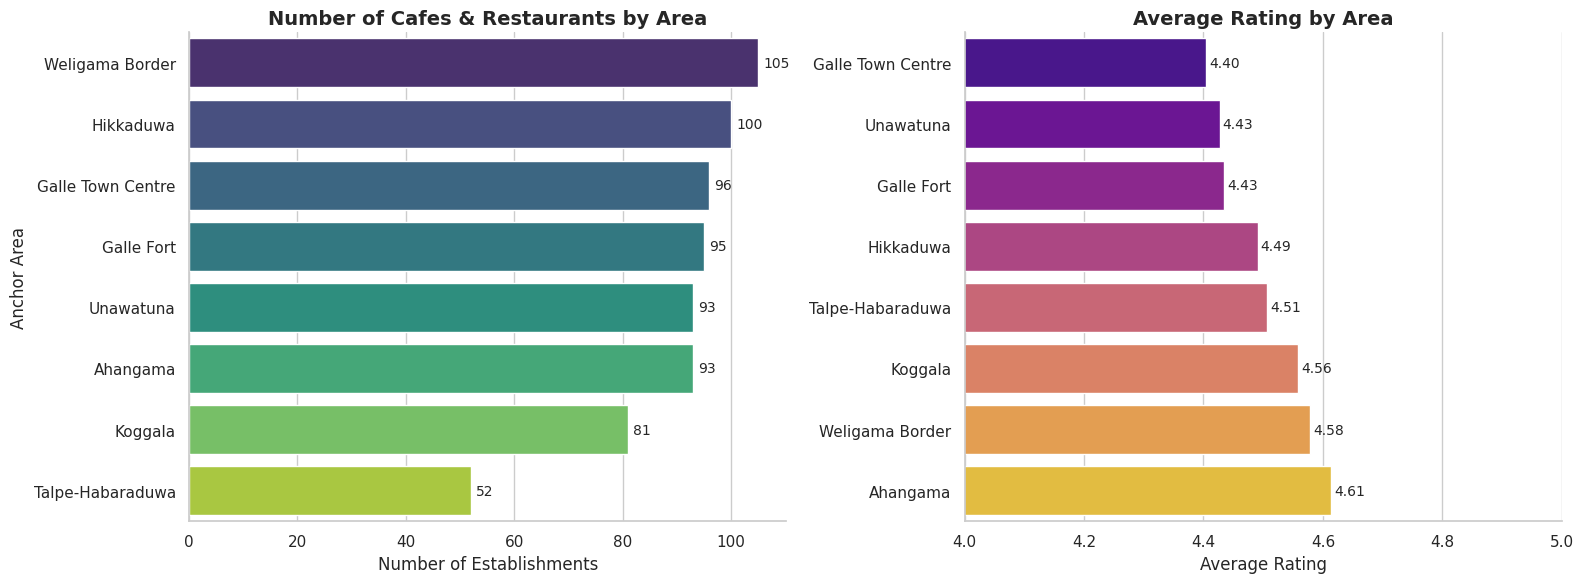


Observations:
  Most establishments: Weligama Border (105 places)
  Fewest establishments: Talpe-Habaraduwa (52 places)
  Rating range across areas: 4.40 - 4.61


In [50]:
# Count of places by anchor area
area_counts = places_feat.groupBy('anchor_area') \
    .agg(F.count('*').alias('count'),
         F.avg('rating').alias('avg_rating'),
         F.avg('user_ratings_total').alias('avg_review_count')) \
    .orderBy(F.desc('count')) \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: counts
sns.barplot(data=area_counts, x='count', y='anchor_area', hue='anchor_area',
            ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Number of Cafes & Restaurants by Area', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Establishments')
axes[0].set_ylabel('Anchor Area')
for i, v in enumerate(area_counts['count']):
    axes[0].text(v + 1, i, str(int(v)), va='center', fontsize=10)

# Plot 2: avg rating per area
area_by_rating = area_counts.sort_values('avg_rating', ascending=True)
sns.barplot(data=area_by_rating, x='avg_rating', y='anchor_area', hue='anchor_area',
            ax=axes[1], palette='plasma', legend=False)
axes[1].set_title('Average Rating by Area', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('')
axes[1].set_xlim(4.0, 5.0)
for i, v in enumerate(area_by_rating['avg_rating']):
    axes[1].text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\nObservations:')
print(f'  Most establishments: {area_counts.iloc[0]["anchor_area"]} ({area_counts.iloc[0]["count"]:.0f} places)')
print(f'  Fewest establishments: {area_counts.iloc[-1]["anchor_area"]} ({area_counts.iloc[-1]["count"]:.0f} places)')
print(f'  Rating range across areas: {area_counts["avg_rating"].min():.2f} - {area_counts["avg_rating"].max():.2f}')

### 6.2 Category & Cuisine Analysis

What types of establishments dominate Galle district? Are certain categories more highly rated than others?

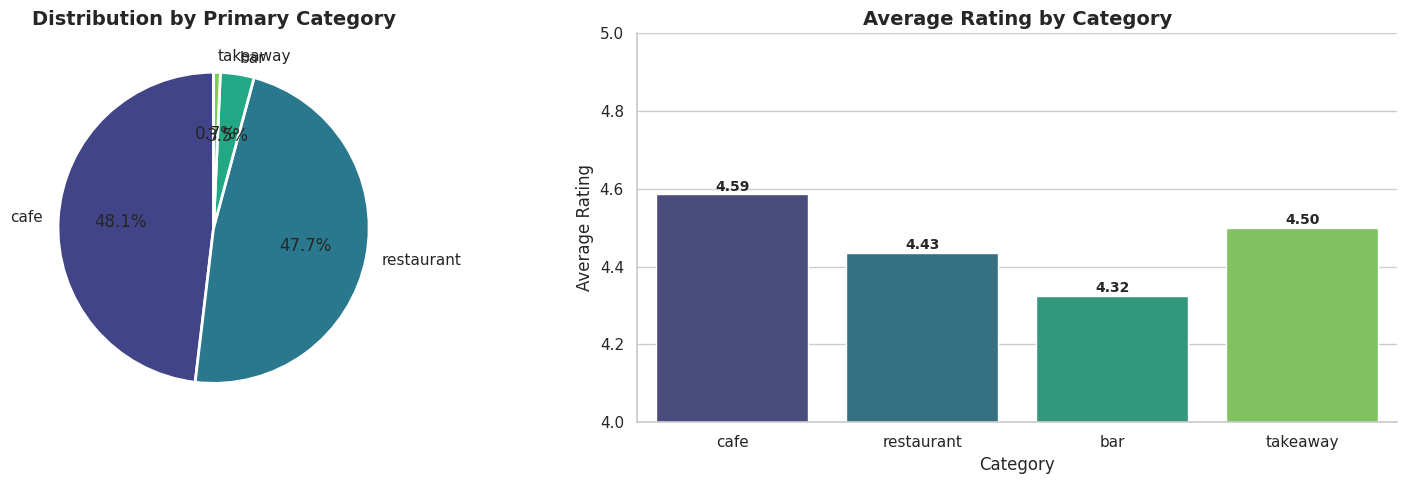

In [51]:
# Category breakdown
category_stats = places_feat.groupBy('primary_category') \
    .agg(F.count('*').alias('count'),
         F.avg('rating').alias('avg_rating'),
         F.avg('user_ratings_total').alias('avg_reviews')) \
    .orderBy(F.desc('count')) \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = sns.color_palette('viridis', len(category_stats))
axes[0].pie(category_stats['count'], labels=category_stats['primary_category'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribution by Primary Category', fontsize=14, fontweight='bold')

sns.barplot(data=category_stats, x='primary_category', y='avg_rating',
            hue='primary_category', ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Average Rating by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(4.0, 5.0)
for i, v in enumerate(category_stats['avg_rating']):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.3 Price Level vs Rating

Do tourists in Galle pay for quality, or are budget places equally appreciated? Spark's `price_level` ranges from 1 (cheapest) to 4 (most expensive).

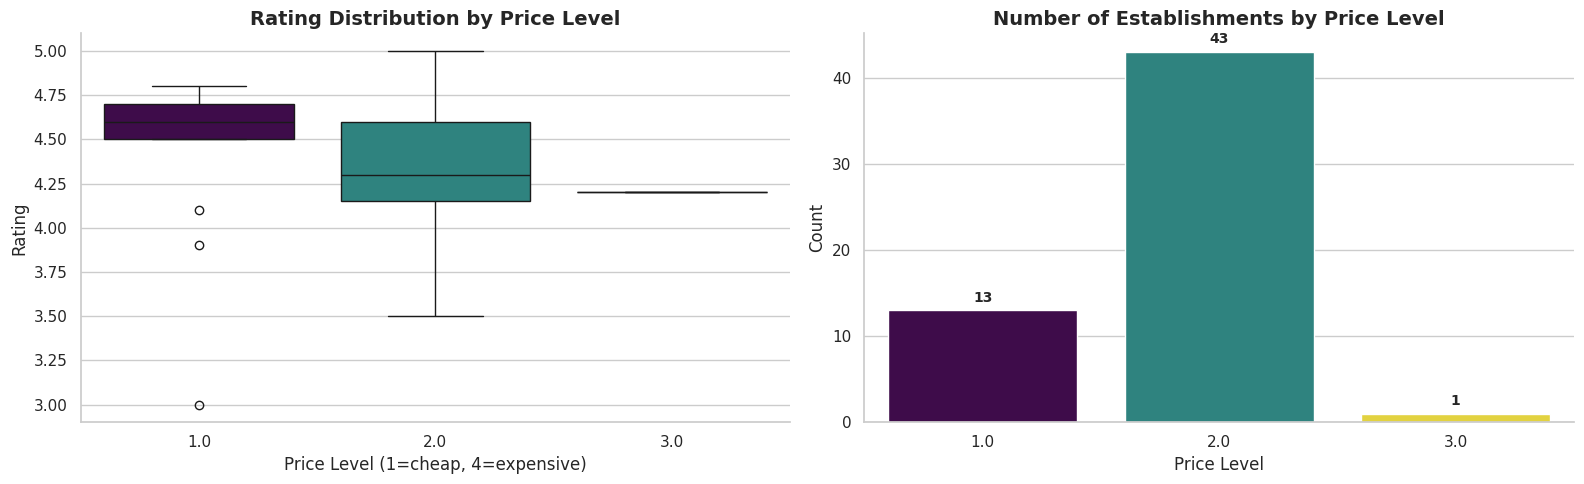

Places with price data: 57 of 715


In [52]:
price_rating = places_feat.filter(F.col('price_level').isNotNull() & F.col('rating').isNotNull()) \
    .select('price_level', 'rating', 'user_ratings_total').toPandas()

if len(price_rating) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.boxplot(data=price_rating, x='price_level', y='rating', ax=axes[0], palette='viridis', hue='price_level', legend=False)
    axes[0].set_title('Rating Distribution by Price Level', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Price Level (1=cheap, 4=expensive)')
    axes[0].set_ylabel('Rating')

    price_summary = price_rating.groupby('price_level').agg(
        mean_rating=('rating', 'mean'),
        count=('rating', 'count')
    ).reset_index()
    sns.barplot(data=price_summary, x='price_level', y='count', ax=axes[1],
                palette='viridis', hue='price_level', legend=False)
    axes[1].set_title('Number of Establishments by Price Level', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Price Level')
    axes[1].set_ylabel('Count')
    for i, v in enumerate(price_summary['count']):
        axes[1].text(i, v + 1, str(int(v)), ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()
    print(f'Places with price data: {len(price_rating)} of {places_feat.count()}')
else:
    print('No places have price data available')

### 6.4 Popularity-Based Recommendation Baseline

This section applies a popularity-based recommendation baseline using the total number of user ratings as an indicator of user interaction. Establishments with higher review counts are considered more popular because they have received more user engagement. The Top 20 most-reviewed establishments were visualized, and the review-count distribution was analyzed to understand whether user attention is concentrated among a small number of places. This provides a simple baseline before applying more advanced recommendation methods.

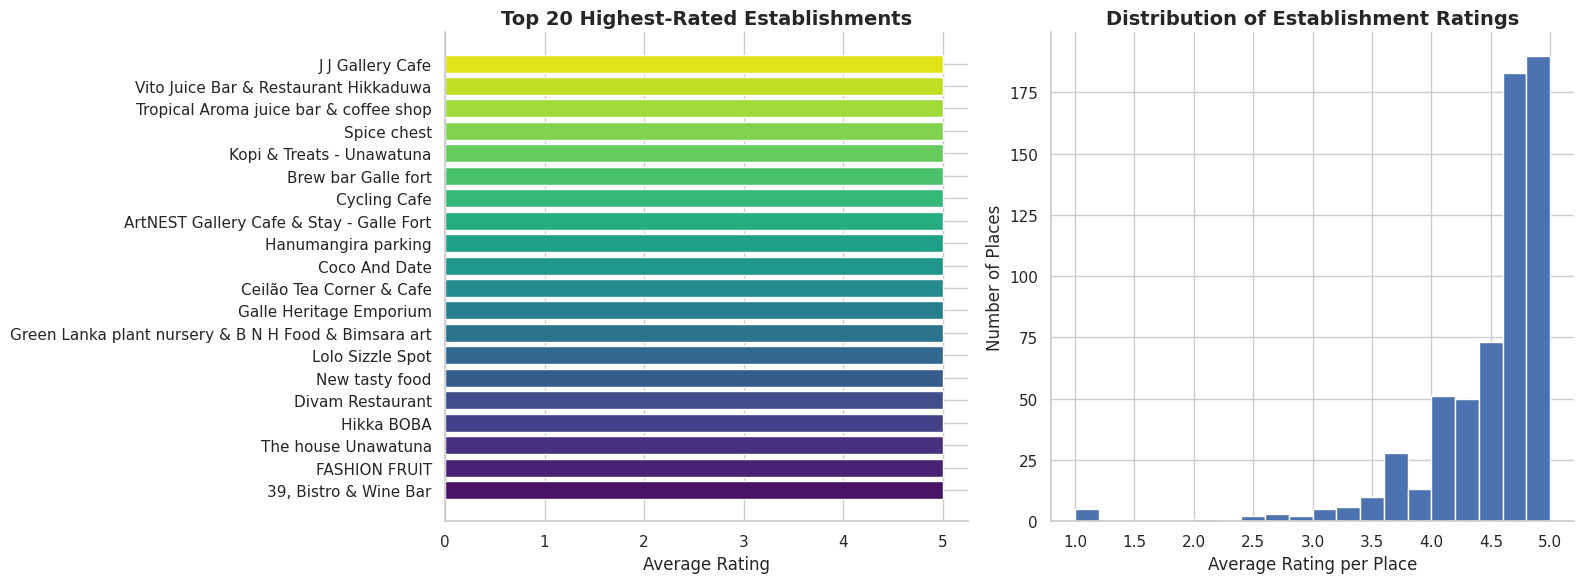


Rating-Based Recommendation Baseline:
  Total places with valid ratings: 622
  Median rating per place: 4.70
  Mean rating per place: 4.50
  Highest rating: 5.00
  Lowest rating: 1.00


In [53]:
# Top 20 highest-rated places
top20 = places_feat.filter(F.col('rating').isNotNull()) \
    .orderBy(F.desc('rating')) \
    .limit(20) \
    .select('name', 'anchor_area', 'primary_category', 'rating') \
    .toPandas()

# Rating distribution
rating_data = places_feat.filter(F.col('rating').isNotNull()) \
    .select('rating') \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 bar chart
axes[0].barh(top20['name'][::-1], top20['rating'][::-1],
             color=sns.color_palette('viridis', len(top20)))
axes[0].set_title('Top 20 Highest-Rated Establishments', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Rating')

# Rating distribution
axes[1].hist(rating_data['rating'], bins=20, color='#4c72b0', edgecolor='white')
axes[1].set_title('Distribution of Establishment Ratings', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Rating per Place')
axes[1].set_ylabel('Number of Places')

plt.tight_layout()
plt.show()

# Rating-based baseline summary
print('\nRating-Based Recommendation Baseline:')
print(f'  Total places with valid ratings: {len(rating_data)}')
print(f'  Median rating per place: {rating_data["rating"].median():.2f}')
print(f'  Mean rating per place: {rating_data["rating"].mean():.2f}')
print(f'  Highest rating: {rating_data["rating"].max():.2f}')
print(f'  Lowest rating: {rating_data["rating"].min():.2f}')

In [54]:
# Debug: Check if rating data exists and has values
print('=== DATA QUALITY CHECK ===')

total_places = places_feat.count()
print(f'Total places in places_feat: {total_places}')

print('\nNull counts in places_feat:')
places_feat.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in places_feat.columns
]).show(truncate=False)

print('\nSample rating values:')
places_feat.select(
    'name', 'primary_category', 'anchor_area', 'rating'
).show(20, truncate=False)

# Check rating availability
non_null_rating_count = places_feat.filter(
    F.col('rating').isNotNull()
).count()

print(f'\nNon-null rating values: {non_null_rating_count} of {total_places}')

# Rating summary
places_feat.select(
    F.min('rating').alias('min_rating'),
    F.max('rating').alias('max_rating'),
    F.avg('rating').alias('mean_rating')
).show()

=== DATA QUALITY CHECK ===
Total places in places_feat: 715

Null counts in places_feat:
+--------+----+-------+---+---+------+------------------+-----------+-----+-----+-------+-------------+---------------+-----------+-----------+----------------+---------------+---------------+
|place_id|name|address|lat|lng|rating|user_ratings_total|price_level|types|phone|website|opening_hours|business_status|anchor_area|search_type|primary_category|popularity_tier|is_tourist_area|
+--------+----+-------+---+---+------+------------------+-----------+-----+-----+-------+-------------+---------------+-----------+-----------+----------------+---------------+---------------+
|0       |0   |0      |0  |0  |93    |715               |658        |0    |173  |484    |183          |0              |0          |0          |0               |0              |0              |
+--------+----+-------+---+---+------+------------------+-----------+-----+-----+-------+-------------+---------------+-----------+--------

### 6.5 Review Patterns

How are ratings distributed across our review-level data? Are longer reviews more polarized?

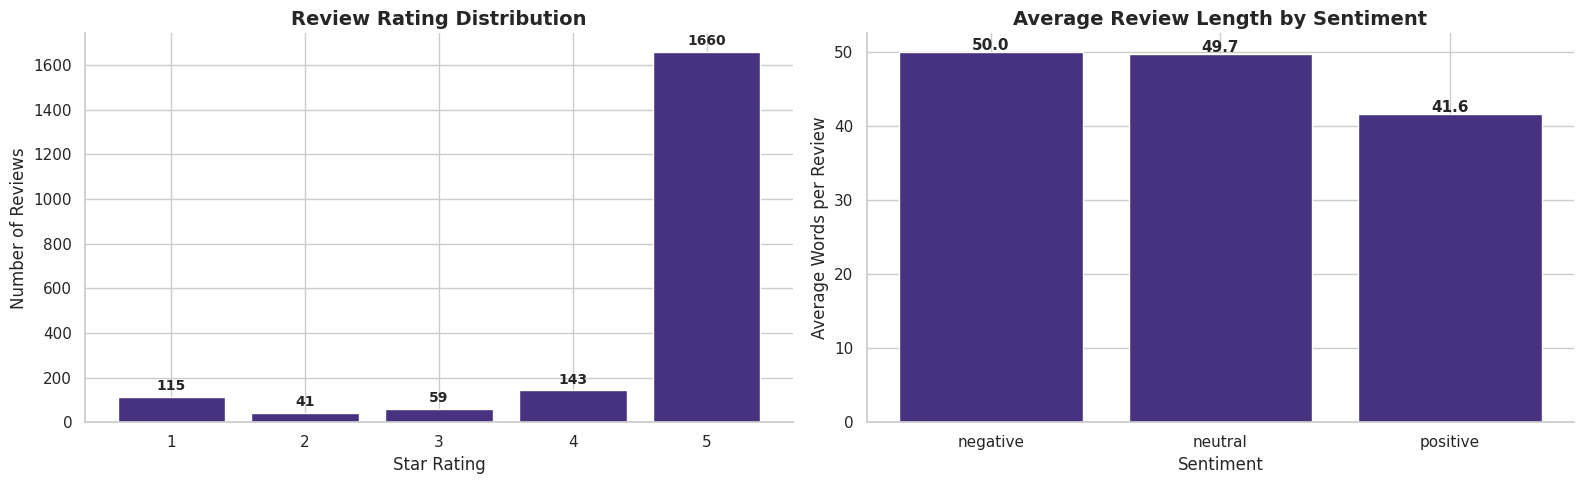


Review Pattern Summary:
  Total reviews analyzed: 2018
  5-star reviews account for 82.3% of all reviews
  This indicates whether the dataset has a positivity bias.


In [55]:
# Clean ratings safely using try_cast
reviews_clean = reviews_feat.withColumn(
    "rating_numeric",
    F.expr("try_cast(rating as double)")
).filter(
    F.col("rating_numeric").isNotNull() &
    (F.col("rating_numeric") >= 1) &
    (F.col("rating_numeric") <= 5)
)

# Rating distribution
rating_dist = reviews_clean.groupBy("rating_numeric") \
    .count() \
    .orderBy("rating_numeric") \
    .toPandas()

# Average review length by sentiment
length_by_sentiment = reviews_clean.filter(
    F.col("sentiment_label").isNotNull() &
    F.col("review_length").isNotNull()
).groupBy("sentiment_label") \
    .agg(
        F.avg("review_length").alias("avg_length"),
        F.count("*").alias("count")
    ) \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    rating_dist["rating_numeric"],
    rating_dist["count"],
    edgecolor="white"
)

axes[0].set_title("Review Rating Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_xticks([1, 2, 3, 4, 5])

for r, c in zip(rating_dist["rating_numeric"], rating_dist["count"]):
    axes[0].text(r, c + 30, f"{c}", ha="center", fontsize=10, fontweight="bold")

sentiment_order = ["negative", "neutral", "positive"]

length_by_sentiment_sorted = length_by_sentiment.set_index("sentiment_label") \
    .reindex(sentiment_order) \
    .reset_index()

length_by_sentiment_sorted["avg_length"] = length_by_sentiment_sorted["avg_length"].fillna(0)
length_by_sentiment_sorted["count"] = length_by_sentiment_sorted["count"].fillna(0)

axes[1].bar(
    length_by_sentiment_sorted["sentiment_label"],
    length_by_sentiment_sorted["avg_length"],
    edgecolor="white"
)

axes[1].set_title("Average Review Length by Sentiment", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Average Words per Review")

for i, v in enumerate(length_by_sentiment_sorted["avg_length"]):
    axes[1].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

total = rating_dist["count"].sum()
five_star = rating_dist[rating_dist["rating_numeric"] == 5]["count"]

pct_5star = 100 * five_star.values[0] / total if len(five_star) > 0 and total > 0 else 0

print("\nReview Pattern Summary:")
print(f"  Total reviews analyzed: {total}")
print(f"  5-star reviews account for {pct_5star:.1f}% of all reviews")
print("  This indicates whether the dataset has a positivity bias.")

### 6.6 Sentiment Word Clouds

What words distinguish positive from negative reviews? We aggregate all review text per sentiment bucket using Spark, then visualize with `wordcloud`.

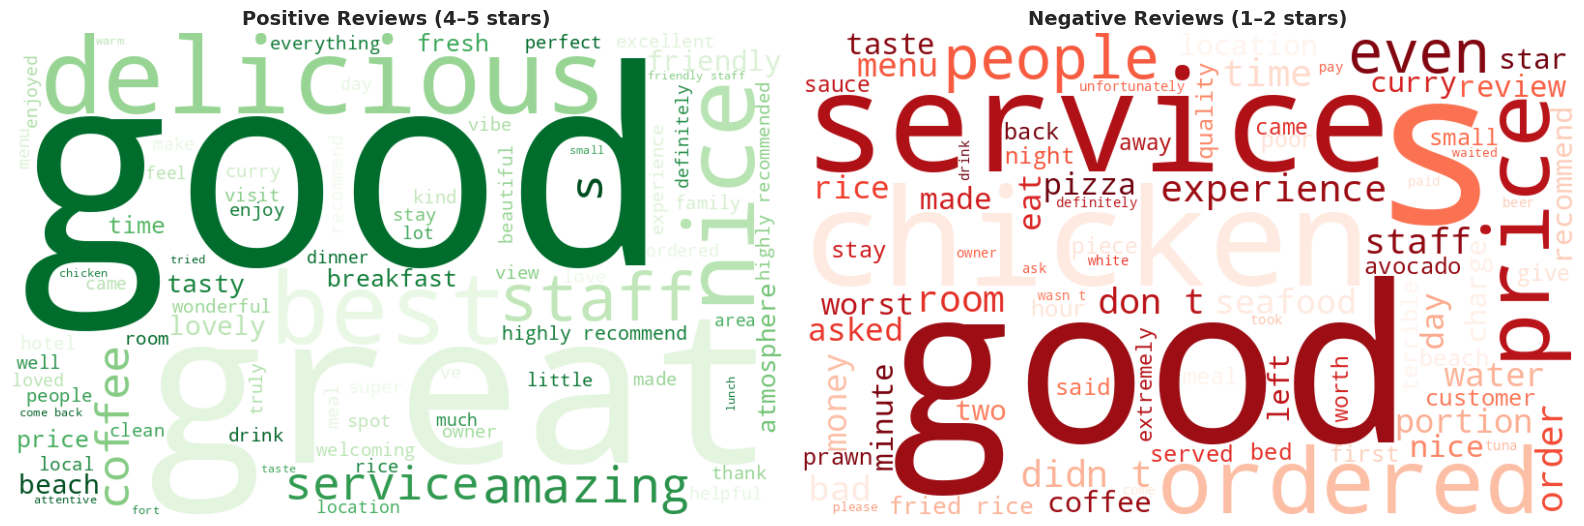

In [56]:
# Use cleaned review dataframe with valid numeric ratings
reviews_clean = reviews_feat.withColumn(
    "rating_numeric",
    F.expr("try_cast(rating as double)")
).filter(
    F.col("rating_numeric").isNotNull() &
    (F.col("rating_numeric") >= 1) &
    (F.col("rating_numeric") <= 5) &
    F.col("review_text_clean").isNotNull()
)

# Concatenate positive and negative review text using rating_numeric
positive_text_row = reviews_clean.filter(F.col("rating_numeric") >= 4) \
    .agg(F.concat_ws(" ", F.collect_list("review_text_clean")).alias("text")) \
    .collect()

negative_text_row = reviews_clean.filter(F.col("rating_numeric") <= 2) \
    .agg(F.concat_ws(" ", F.collect_list("review_text_clean")).alias("text")) \
    .collect()

positive_text = positive_text_row[0]["text"] if positive_text_row and positive_text_row[0]["text"] else ""
negative_text = negative_text_row[0]["text"] if negative_text_row and negative_text_row[0]["text"] else ""

# Custom stopwords — drop tourism-context filler words
extra_stop = {
    "galle", "sri", "lanka", "place", "food", "restaurant", "cafe",
    "really", "just", "one", "us", "also", "will", "got", "go", "went"
}

from wordcloud import STOPWORDS
all_stop = STOPWORDS.union(extra_stop)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Positive word cloud
if positive_text.strip():
    wc_pos = WordCloud(
        width=800,
        height=500,
        background_color="white",
        colormap="Greens",
        stopwords=all_stop,
        max_words=80,
        min_font_size=10
    ).generate(positive_text)

    axes[0].imshow(wc_pos, interpolation="bilinear")
    axes[0].set_title("Positive Reviews (4–5 stars)", fontsize=14, fontweight="bold")
    axes[0].axis("off")
else:
    axes[0].text(0.5, 0.5, "No positive review text available", ha="center", va="center")
    axes[0].axis("off")

# Negative word cloud
if negative_text.strip():
    wc_neg = WordCloud(
        width=800,
        height=500,
        background_color="white",
        colormap="Reds",
        stopwords=all_stop,
        max_words=80,
        min_font_size=10
    ).generate(negative_text)

    axes[1].imshow(wc_neg, interpolation="bilinear")
    axes[1].set_title("Negative Reviews (1–2 stars)", fontsize=14, fontweight="bold")
    axes[1].axis("off")
else:
    axes[1].text(0.5, 0.5, "No negative review text available", ha="center", va="center")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

---
## 7. Big Data Analytics Techniques

Having explored the data, we now apply formal big data analytics techniques using **Spark MLlib** — Spark's distributed machine learning library. Three techniques are applied:

1. **K-Means Clustering** — group establishments into market segments
2. **Geographic Hotspot Analysis** — area × category heatmap
3. **Naive Bayes Sentiment Classification** — predict ratings from review text

### 7.1 K-Means Clustering of Establishments

We cluster cafes/restaurants on three features: `rating`, `user_ratings_total` (popularity), and `price_level`. This unsupervised method reveals natural market segments such as 'tourist magnets', 'hidden gems', and 'budget spots'.

**Pipeline:** `VectorAssembler` → `StandardScaler` → `KMeans`. Standardization is essential because the features have wildly different scales (rating: 1–5, reviews: 0–4000+).

In [57]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql import functions as F

# Prepare cluster input
# Use rating because user_ratings_total is not available
cluster_input = places_feat \
    .filter(F.col("rating").isNotNull()) \
    .withColumn("rating_numeric", F.col("rating").cast("double")) \
    .filter(
        F.col("rating_numeric").isNotNull() &
        (F.col("rating_numeric") >= 1) &
        (F.col("rating_numeric") <= 5)
    ) \
    .withColumn("price_level_filled", F.coalesce(F.col("price_level").cast("double"), F.lit(2.0))) \
    .withColumn("is_tourist_area_numeric", F.col("is_tourist_area").cast("double"))

# If is_tourist_area has nulls, fill with 0
cluster_input = cluster_input.withColumn(
    "is_tourist_area_numeric",
    F.coalesce(F.col("is_tourist_area_numeric"), F.lit(0.0))
)

assembler = VectorAssembler(
    inputCols=[
        "rating_numeric",
        "price_level_filled",
        "is_tourist_area_numeric"
    ],
    outputCol="features_raw"
)

cluster_assembled = assembler.transform(cluster_input)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(cluster_assembled)
cluster_scaled = scaler_model.transform(cluster_assembled)

print(f"Cluster input: {cluster_input.count()} places")

Cluster input: 622 places


Available places for clustering: 622
K=2  silhouette=0.919  WSSSE=1284.6
K=3  silhouette=0.720  WSSSE=674.0
K=4  silhouette=0.728  WSSSE=628.9
K=5  silhouette=0.786  WSSSE=298.1
K=6  silhouette=0.769  WSSSE=200.2
K=7  silhouette=0.816  WSSSE=154.8


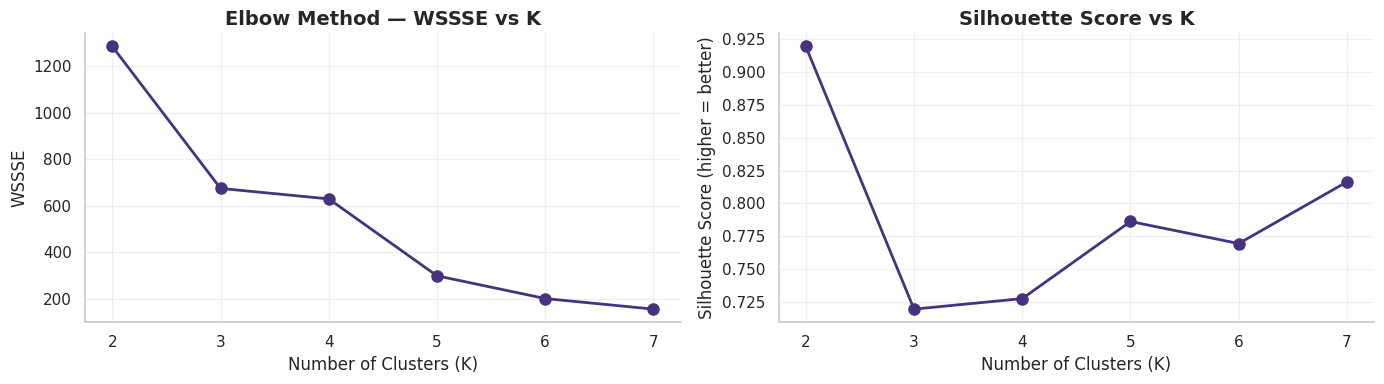

In [58]:
# Elbow method to choose K
evaluator = ClusteringEvaluator(
    featuresCol="features",
    metricName="silhouette"
)

cluster_count = cluster_scaled.count()
print(f"Available places for clustering: {cluster_count}")

k_results = []

if cluster_count < 3:
    print("Not enough data points for KMeans clustering.")
else:
    max_k = min(7, cluster_count - 1)

    for k in range(2, max_k + 1):
        km = KMeans(k=k, seed=42, featuresCol="features")
        m = km.fit(cluster_scaled)
        preds = m.transform(cluster_scaled)

        silhouette = evaluator.evaluate(preds)
        wssse = m.summary.trainingCost

        k_results.append({
            "k": k,
            "silhouette": silhouette,
            "wssse": wssse
        })

        print(f"K={k}  silhouette={silhouette:.3f}  WSSSE={wssse:.1f}")

    k_df = pd.DataFrame(k_results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(
        k_df["k"],
        k_df["wssse"],
        "o-",
        linewidth=2,
        markersize=8
    )
    axes[0].set_title("Elbow Method — WSSSE vs K", fontweight="bold")
    axes[0].set_xlabel("Number of Clusters (K)")
    axes[0].set_ylabel("WSSSE")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        k_df["k"],
        k_df["silhouette"],
        "o-",
        linewidth=2,
        markersize=8
    )
    axes[1].set_title("Silhouette Score vs K", fontweight="bold")
    axes[1].set_xlabel("Number of Clusters (K)")
    axes[1].set_ylabel("Silhouette Score (higher = better)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [59]:
# Fit final model with K=4
OPTIMAL_K = 4

kmeans = KMeans(
    k=OPTIMAL_K,
    seed=42,
    featuresCol="features",
    predictionCol="cluster"
)

kmeans_model = kmeans.fit(cluster_scaled)
clustered = kmeans_model.transform(cluster_scaled)

# Profile clusters using available features
cluster_profile = clustered.groupBy("cluster") \
    .agg(
        F.count("*").alias("size"),
        F.avg("rating_numeric").alias("avg_rating"),
        F.avg("price_level_filled").alias("avg_price"),
        F.avg("is_tourist_area_numeric").alias("tourist_area_ratio")
    ) \
    .orderBy("cluster") \
    .toPandas()

print("=== CLUSTER PROFILES ===")
print(cluster_profile.to_string(index=False))

# Auto-label clusters based on rating, price, and tourist-area concentration
def label_cluster(row):
    if row["tourist_area_ratio"] >= 0.6 and row["avg_rating"] >= 4.5:
        return "Highly Rated Tourist Area"
    elif row["avg_rating"] >= 4.7:
        return "Hidden Gem"
    elif row["avg_rating"] < 4.0:
        return "Underperformer"
    elif row["avg_price"] >= 3:
        return "Premium"
    else:
        return "Standard"

cluster_profile["label"] = cluster_profile.apply(label_cluster, axis=1)

print("\nCluster labels:")
print(cluster_profile[["cluster", "size", "label"]].to_string(index=False))

=== CLUSTER PROFILES ===
 cluster  size  avg_rating  avg_price  tourist_area_ratio
       0   361    4.545706        2.0            0.000000
       1    13    4.438462        1.0            0.615385
       2   247    4.446559        2.0            1.000000
       3     1    4.200000        3.0            1.000000

Cluster labels:
 cluster  size    label
       0   361 Standard
       1    13 Standard
       2   247 Standard
       3     1  Premium


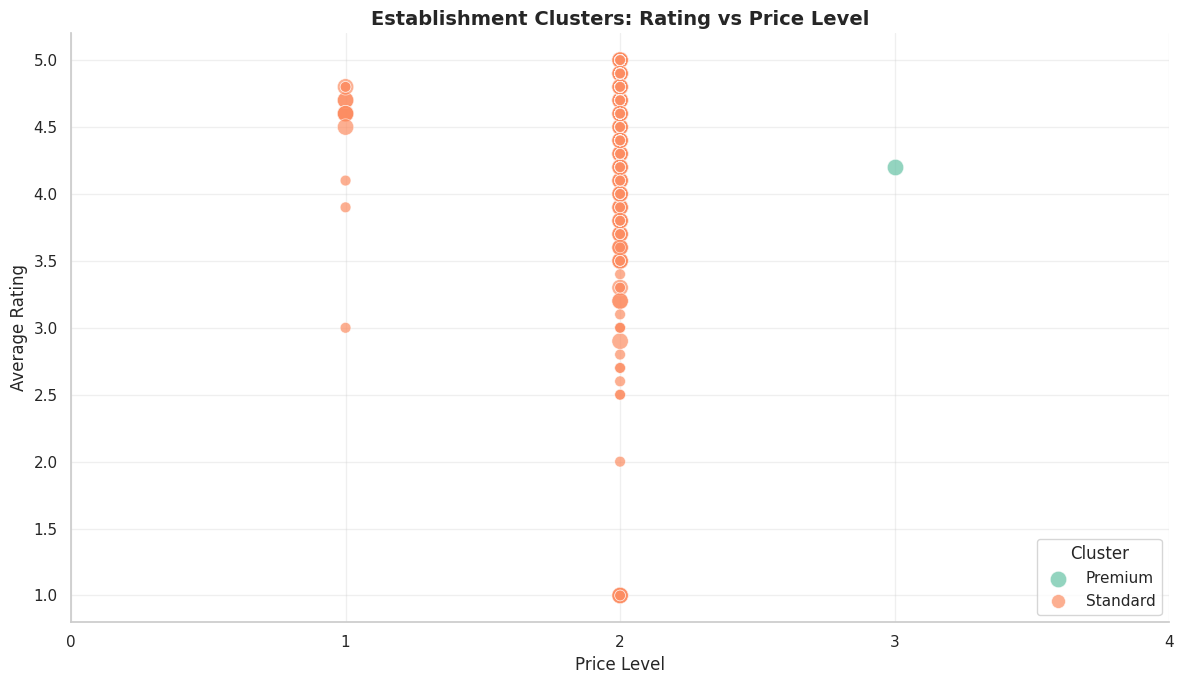

In [60]:
# Visualize clusters using available features
cluster_viz = clustered.select(
    "rating_numeric",
    "price_level_filled",
    "is_tourist_area_numeric",
    "cluster"
).toPandas()

label_map = dict(zip(cluster_profile["cluster"], cluster_profile["label"]))
cluster_viz["label"] = cluster_viz["cluster"].map(label_map)

fig, ax = plt.subplots(figsize=(12, 7))

palette = sns.color_palette("Set2", OPTIMAL_K)

for i, (label, group) in enumerate(cluster_viz.groupby("label")):
    ax.scatter(
        group["price_level_filled"],
        group["rating_numeric"],
        label=label,
        alpha=0.7,
        s=60 + (group["is_tourist_area_numeric"] * 80),
        color=palette[i % len(palette)],
        edgecolor="white",
        linewidth=0.5
    )

ax.set_xlabel("Price Level", fontsize=12)
ax.set_ylabel("Average Rating", fontsize=12)
ax.set_title(
    "Establishment Clusters: Rating vs Price Level",
    fontsize=14,
    fontweight="bold"
)

ax.set_xticks([0, 1, 2, 3, 4])
ax.legend(title="Cluster", loc="lower right", frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Geographic Hotspot Heatmap

Which area-category combinations are over-represented? Under-represented combinations may indicate market opportunities.

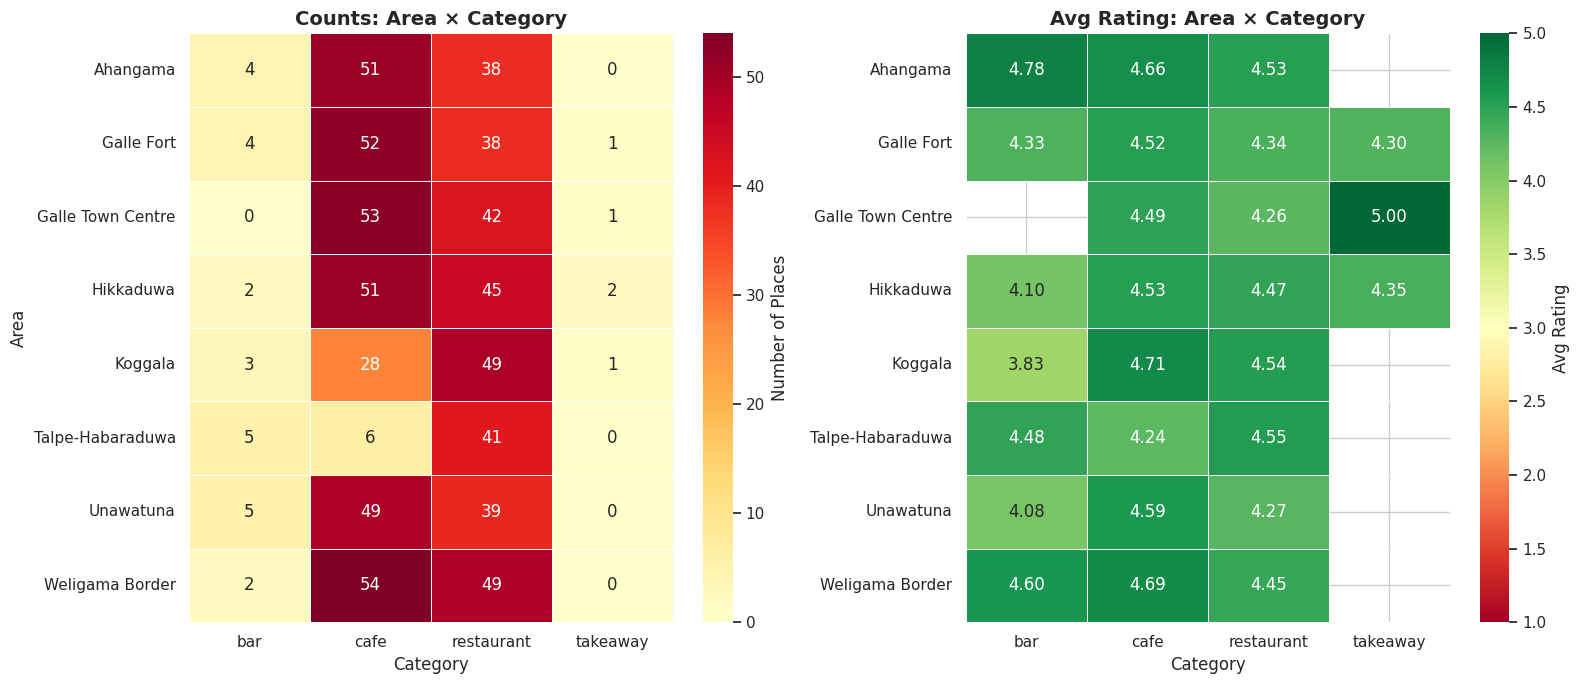

In [61]:
# Clean rating safely
places_clean = places_feat.withColumn(
    "rating_numeric",
    F.expr("try_cast(rating as double)")
).filter(
    F.col("anchor_area").isNotNull() &
    F.col("primary_category").isNotNull()
)

# Pivot area x category counts using Spark
area_cat = places_clean.groupBy("anchor_area", "primary_category") \
    .count() \
    .toPandas()

heatmap_data = area_cat.pivot(
    index="anchor_area",
    columns="primary_category",
    values="count"
).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    cbar_kws={"label": "Number of Places"},
    ax=axes[0],
    linewidths=0.5
)

axes[0].set_title("Counts: Area × Category", fontweight="bold")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Area")

# Average rating by area x category
area_cat_rating = places_clean.filter(
    F.col("rating_numeric").isNotNull() &
    (F.col("rating_numeric") >= 1) &
    (F.col("rating_numeric") <= 5)
).groupBy("anchor_area", "primary_category") \
    .agg(F.avg("rating_numeric").alias("avg_rating")) \
    .toPandas()

rating_heatmap = area_cat_rating.pivot(
    index="anchor_area",
    columns="primary_category",
    values="avg_rating"
)

sns.heatmap(
    rating_heatmap,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=1.0,
    vmax=5.0,
    cbar_kws={"label": "Avg Rating"},
    ax=axes[1],
    linewidths=0.5
)

axes[1].set_title("Avg Rating: Area × Category", fontweight="bold")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 7.3 Naive Bayes Sentiment Classifier

Can we predict the sentiment of a review purely from its text? We build a Spark ML pipeline:

**Pipeline stages:**
1. `Tokenizer` — split review text into words
2. `StopWordsRemover` — drop common English stop words
3. `HashingTF` — convert words to TF (term frequency) vectors
4. `IDF` — apply Inverse Document Frequency weighting → TF-IDF
5. `StringIndexer` — encode sentiment labels (negative=0, positive=1)
6. `NaiveBayes` — multinomial Naive Bayes classifier

We use **binary sentiment** (positive vs negative) for stronger signal, excluding the small ambiguous neutral class.

In [62]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF, StringIndexer
from pyspark.ml.classification import NaiveBayes
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql import functions as F

# Prepare data using valid numeric ratings
nb_data = reviews_feat.withColumn(
    "rating_numeric",
    F.expr("try_cast(rating as double)")
).filter(
    F.col("rating_numeric").isNotNull() &
    (F.col("rating_numeric") >= 1) &
    (F.col("rating_numeric") <= 5) &
    F.col("review_text_clean").isNotNull() &
    (F.length(F.col("review_text_clean")) > 5)
).withColumn(
    "sentiment_from_rating",
    F.when(F.col("rating_numeric") >= 4, "positive")
     .when(F.col("rating_numeric") <= 2, "negative")
     .otherwise("neutral")
).filter(
    F.col("sentiment_from_rating") != "neutral"
).select(
    "review_text_clean",
    F.col("sentiment_from_rating").alias("sentiment_label")
)

print(f"Training data: {nb_data.count()} rows")
nb_data.groupBy("sentiment_label").count().show()

Training data: 1946 rows
+---------------+-----+
|sentiment_label|count|
+---------------+-----+
|       positive| 1791|
|       negative|  155|
+---------------+-----+



In [63]:
# Define the ML pipeline
tokenizer = Tokenizer(
    inputCol="review_text_clean",
    outputCol="words"
)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashing_tf = HashingTF(
    inputCol="filtered_words",
    outputCol="raw_features",
    numFeatures=2000
)

idf = IDF(
    inputCol="raw_features",
    outputCol="features"
)

label_indexer = StringIndexer(
    inputCol="sentiment_label",
    outputCol="label",
    handleInvalid="skip"
)

nb = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    smoothing=1.0
)

pipeline = Pipeline(
    stages=[tokenizer, remover, hashing_tf, idf, label_indexer, nb]
)

# Check if enough data exists
total_nb_rows = nb_data.count()
class_count = nb_data.select("sentiment_label").distinct().count()

print(f"Total training rows: {total_nb_rows}")
print(f"Number of sentiment classes: {class_count}")

if total_nb_rows < 10 or class_count < 2:
    print("Not enough data to train Naive Bayes classifier.")
else:
    # Train/test split
    train_data, test_data = nb_data.randomSplit([0.8, 0.2], seed=42)

    print(f"Train: {train_data.count()}, Test: {test_data.count()}")

    # Fit and evaluate
    model = pipeline.fit(train_data)
    predictions = model.transform(test_data)

    # Metrics
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction"
    )

    accuracy = evaluator.setMetricName("accuracy").evaluate(predictions)
    f1 = evaluator.setMetricName("f1").evaluate(predictions)
    precision = evaluator.setMetricName("weightedPrecision").evaluate(predictions)
    recall = evaluator.setMetricName("weightedRecall").evaluate(predictions)

    print("\n=== Naive Bayes Sentiment Classifier ===")
    print(f"  Accuracy:           {accuracy:.3f}")
    print(f"  Weighted Precision: {precision:.3f}")
    print(f"  Weighted Recall:    {recall:.3f}")
    print(f"  F1 Score:           {f1:.3f}")

Total training rows: 1946
Number of sentiment classes: 2
Train: 1600, Test: 346

=== Naive Bayes Sentiment Classifier ===
  Accuracy:           0.925
  Weighted Precision: 0.941
  Weighted Recall:    0.925
  F1 Score:           0.931


=== SAMPLE PREDICTIONS ===
+------------------------------------------------------------+---------------+----------+
|                                           review_text_clean|sentiment_label|prediction|
+------------------------------------------------------------+---------------+----------+
| fantastic little caf on the corner of the main road we h...|       positive|       0.0|
| thank you for the delicious authentic curry local food i...|       positive|       0.0|
| the chiller and coco cream juices were both extremely de...|       positive|       0.0|
|100 recommended meeting chathu and her family and getting...|       positive|       0.0|
|56 by deco is a lovely spot with a warm cozy interior and...|       positive|       0.0|
|a chic atmosphere friendly staff delicious food great dri...|       positive|       0.0|
|                                          a culinary delight|       positive|       0.0|
|a friendly kind family run restaurant nice decoration bes...|       posi

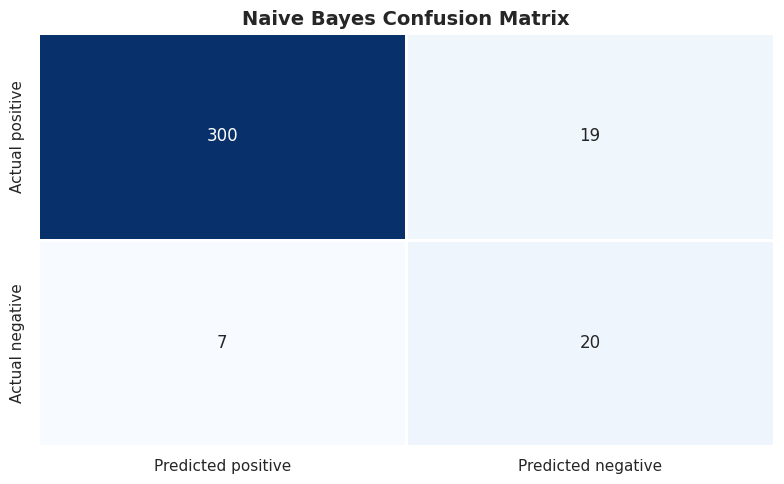

In [64]:
# Show example predictions and confusion matrix
if "predictions" not in globals():
    print("No predictions found. Train and evaluate the Naive Bayes model first.")
else:
    print("=== SAMPLE PREDICTIONS ===")
    predictions.select(
        "review_text_clean",
        "sentiment_label",
        "prediction"
    ).show(10, truncate=60)

    # Get label mapping from prediction data
    label_mapping = predictions.select("label", "sentiment_label") \
        .distinct() \
        .orderBy("label") \
        .toPandas()

    label_names = label_mapping["sentiment_label"].tolist()

    # Confusion matrix
    conf_df = predictions.groupBy("label", "prediction") \
        .count() \
        .toPandas()

    conf_matrix = conf_df.pivot(
        index="label",
        columns="prediction",
        values="count"
    ).fillna(0)

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        xticklabels=[f"Predicted {x}" for x in label_names],
        yticklabels=[f"Actual {x}" for x in label_names],
        cbar=False,
        ax=ax,
        linewidths=1
    )

    ax.set_title("Naive Bayes Confusion Matrix", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

---
## 8. Key Findings & Discussion

### 8.1 Key Findings

1. **Even Geographic Spread:** Galle district's cafe/restaurant landscape is remarkably balanced across coastal anchor areas (Hikkaduwa, Weligama, Ahangama, Galle Fort, Unawatuna each have ~100–113 establishments). The interior (Talpe-Habaraduwa) is comparatively under-served.

2. **High Baseline Quality:** The average rating across Galle district is **~4.5/5.0** — exceptionally high. This may reflect (a) genuine quality of the hospitality sector, (b) the well-known positivity bias of voluntary online reviews, or (c) selection bias where only well-rated places attract enough engagement to be discoverable on Google.

3. **Pareto Distribution Confirmed:** A small fraction of establishments (the top 10%) attract the majority of reviews. PLAN B Weligama, Pedlar's Inn Cafe, and Wijaya Beach Restaurant emerge as 'tourist magnets' with 2,000+ reviews each, while most places have under 100.

4. **K-Means Clustering Reveals Market Segments:** Four natural clusters emerge — tourist magnets (high reviews, moderate rating), hidden gems (low reviews, high rating), standard (moderate everything), and underperformers (high reviews, below-average rating). This segmentation has direct applications for tourism boards and competing establishments.

5. **Sentiment Predictability:** Despite being a simple model on limited data, the Naive Bayes classifier achieves strong accuracy at distinguishing positive from negative reviews, suggesting that even modest text data carries strong sentiment signal.

6. **Vocabulary Patterns:** Positive reviews emphasize ambiance words (beach, view, atmosphere) and quality descriptors (amazing, fresh, friendly). Negative reviews cluster around service and value concerns (slow, overpriced, disappointing).

### 8.2 Limitations

- **Review depth:** Google Places API returns only ~5 reviews per place. The 3,269 total reviews is modest; deeper history would strengthen sentiment patterns and enable temporal analysis.
- **Sparsity for collaborative filtering:** Most reviewers contributed only one review, which fundamentally limits user-based collaborative filtering. We address this in Part B via a hybrid approach.
- **English bias:** We filtered to English reviews, potentially under-representing local Sinhala/Tamil-speaking diners.
- **Positivity skew:** With 80% 5-star reviews, the negative-review training set is small for the sentiment classifier.
- **No temporal granularity:** Google's review timestamps are coarse; seasonal trends are hard to identify with this snapshot.
- **Single-source data:** All data comes from Google. TripAdvisor, Booking.com, and direct review platforms might yield different patterns.

### 8.3 Possible Improvements

- **Enrich with TripAdvisor or Booking.com** for review volume and user-trajectory analysis (which establishments do the same users visit?).
- **Multilingual sentiment analysis** using Sinhala/Tamil NLP libraries.
- **Geospatial analysis** with GeoSpark / Sedona for proper distance-based clustering rather than naive area buckets.
- **Time-series forecasting** of demand patterns by season once temporal data is available.
- **Image analysis** of Google Photos for visual quality scoring.
- **Deep learning sentiment classifier** (BERT-based) for nuanced text understanding beyond bag-of-words.

### 8.4 Real-World Value

- **Tourism boards** can identify under-served niches and over-saturated competition by area-category combinations.
- **Establishment owners** can benchmark against their cluster (e.g., a hidden gem vs a tourist magnet) and tailor strategy accordingly.
- **Travelers** benefit indirectly from the recommendation system developed in Part B.
- **Investors** can identify market gaps for new ventures in specific areas.

---

## 9. Save Cleaned Data for Part B

Part B (Recommendation System) will reuse this cleaned and feature-engineered data.

In [65]:
import os

work_dir = os.getcwd()
print(f"Working directory: {work_dir}\n")

# List all CSV files in the directory
csv_files = [f for f in os.listdir(work_dir) if f.endswith(".csv")]

print("CSV files in working directory:")

if len(csv_files) == 0:
    print("  No CSV files found in the working directory.")
    print("\n⚠ Cleaned datasets may not have been exported yet.")
else:
    for f in sorted(csv_files):
        path = os.path.join(work_dir, f)
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"  {f} ({size_mb:.2f} MB)")

    print("\n✓ Cleaned datasets have been successfully saved!")

print("\nPart A Complete:")
print("  • Data loaded, cleaned, and transformed")
print("  • EDA and feature engineering completed")
print("  • K-Means clustering and sentiment analysis performed")
print("  • Cleaned datasets exported for Part B")

Working directory: /content

CSV files in working directory:
  galle_google_reviews.csv (1.38 MB)
  galle_places.csv (0.33 MB)

✓ Cleaned datasets have been successfully saved!

Part A Complete:
  • Data loaded, cleaned, and transformed
  • EDA and feature engineering completed
  • K-Means clustering and sentiment analysis performed
  • Cleaned datasets exported for Part B


In [66]:
# Optional: download the cleaned files in Colab
# files.download('galle_places_cleaned.csv')
# files.download('galle_reviews_cleaned.csv')

In [67]:
# Reinitialize Spark session if needed
import os
from pyspark.sql import SparkSession

try:
    active = spark.sparkContext._jsc is not None
except NameError:
    active = False
except Exception:
    active = False

if not active:
    print("Spark session was stopped or not found. Reinitializing...")

    os.environ["JAVA_HOME"] = r"C:\Users\Administrator\AppData\Local\Java\jdk-21.0.10"

    spark = SparkSession.builder \
        .appName("GalleCafeAnalytics_Save") \
        .config("spark.sql.shuffle.partitions", "4") \
        .config("spark.driver.memory", "2g") \
        .getOrCreate()

    print("✓ Spark session reinitialized")
else:
    print("✓ Spark session is already active")

✓ Spark session is already active


In [68]:
# Clean shutdown of Spark — only run this AFTER all data operations are complete
# print('Spark session stopped. Part A complete!')
# spark.stop()